[2026-07-16 13:46:44] [info     ] 推理区间：2024-10-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-07-16 15:15:01] [info     ] model scores ready             days=61 rows=111742 score_std=0.440046
[2026-07-16 15:15:01] [info     ] pool align                     hit_rate=0.9805 pool_rows=61000
[2026-07-16 15:15:01] [info     ] prediction finished            elapsed=5297 rows=61000
[2026-07-16 15:15:01] [info     ] 推理完成：61000 行，覆盖 61 个交易日
        date instrument     score
0 2024-10-08  000012.SZ -1.675157
1 2024-10-08  000016.SZ -1.554770
2 2024-10-08  000019.SZ -1.802922
3 2024-10-08  000025.SZ -2.032684
4 2024-10-08  000028.SZ -1.760623
[2026-07-16 15:15:01] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-07-16 15:15:02] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-07-16 15:15:02] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2024-10-08 至 2024-12-31
[2026-07-16 15:15:02] [info     ] ========== 数据检查 ==========
[2026-07-16 15:15:02] [info     ] 通过：列名检查（date/instrumen

时段,IC
2024-09-24~2024-10-08,0.1452

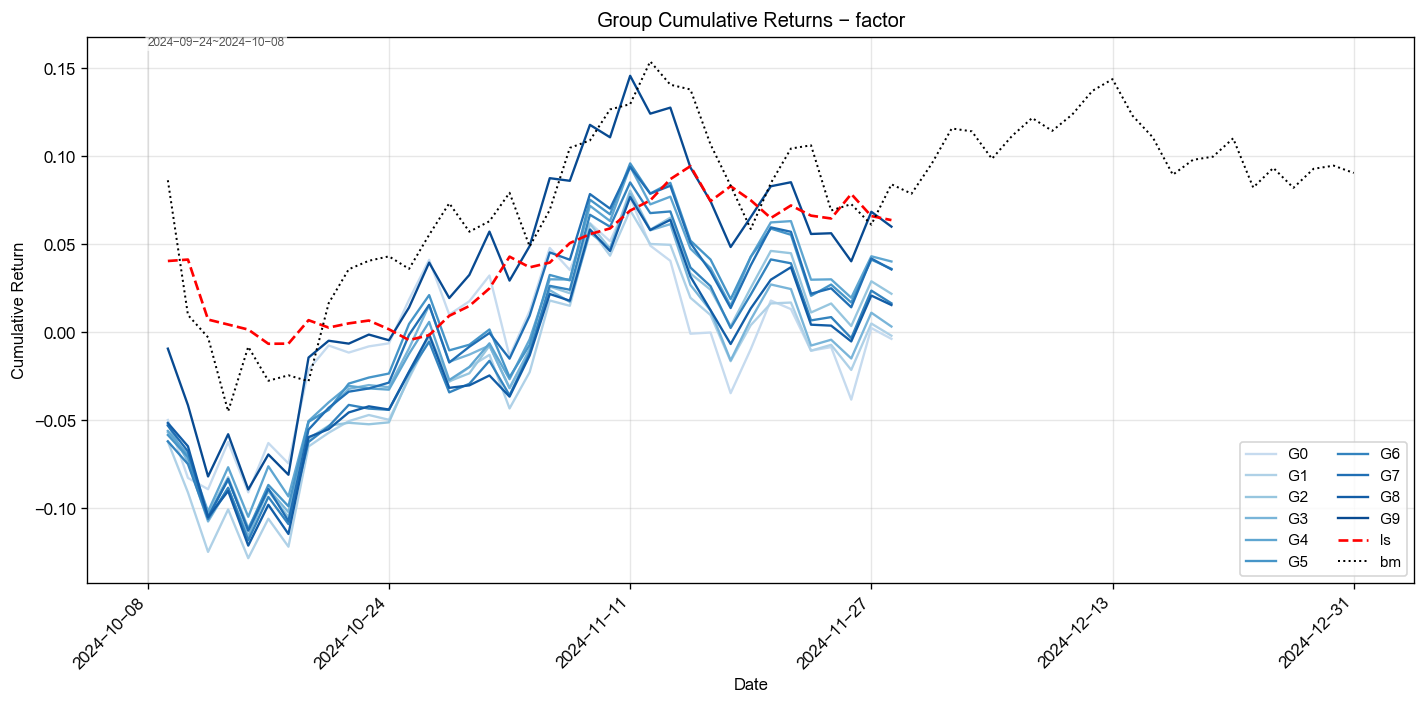
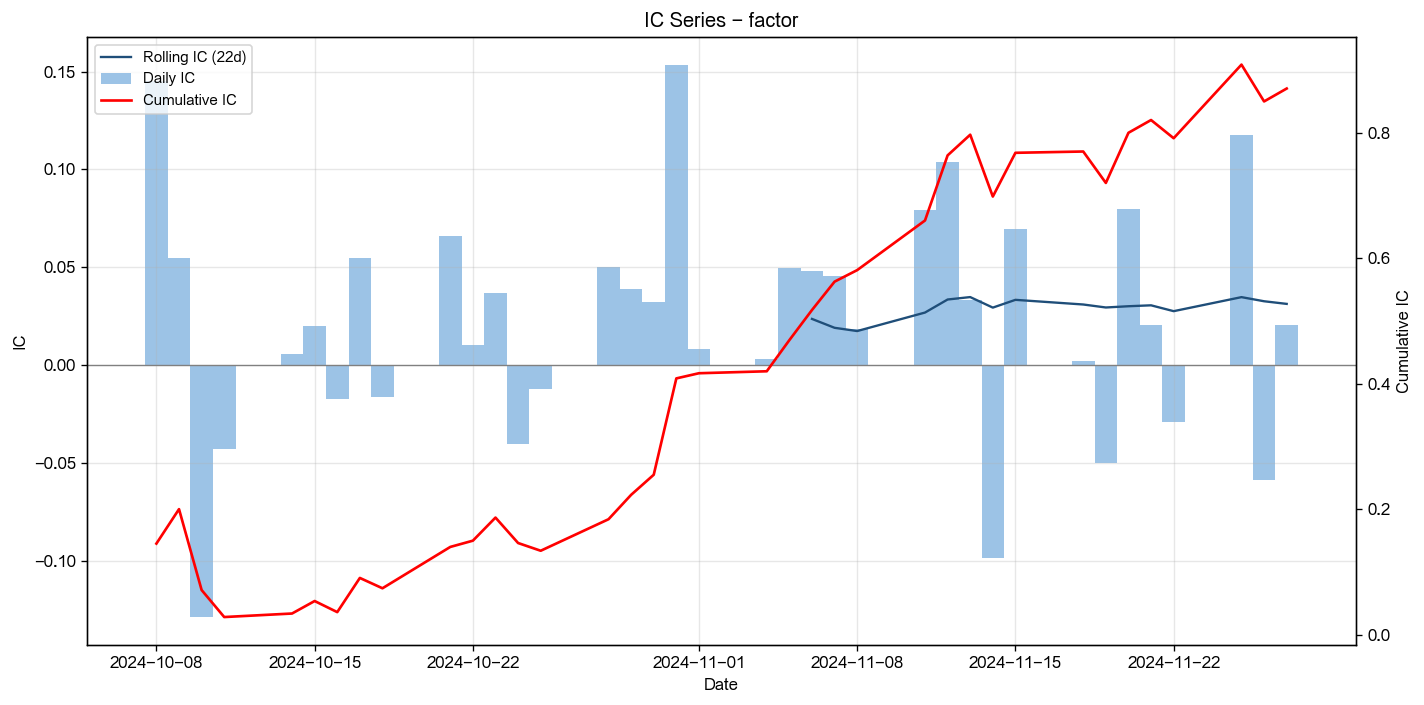
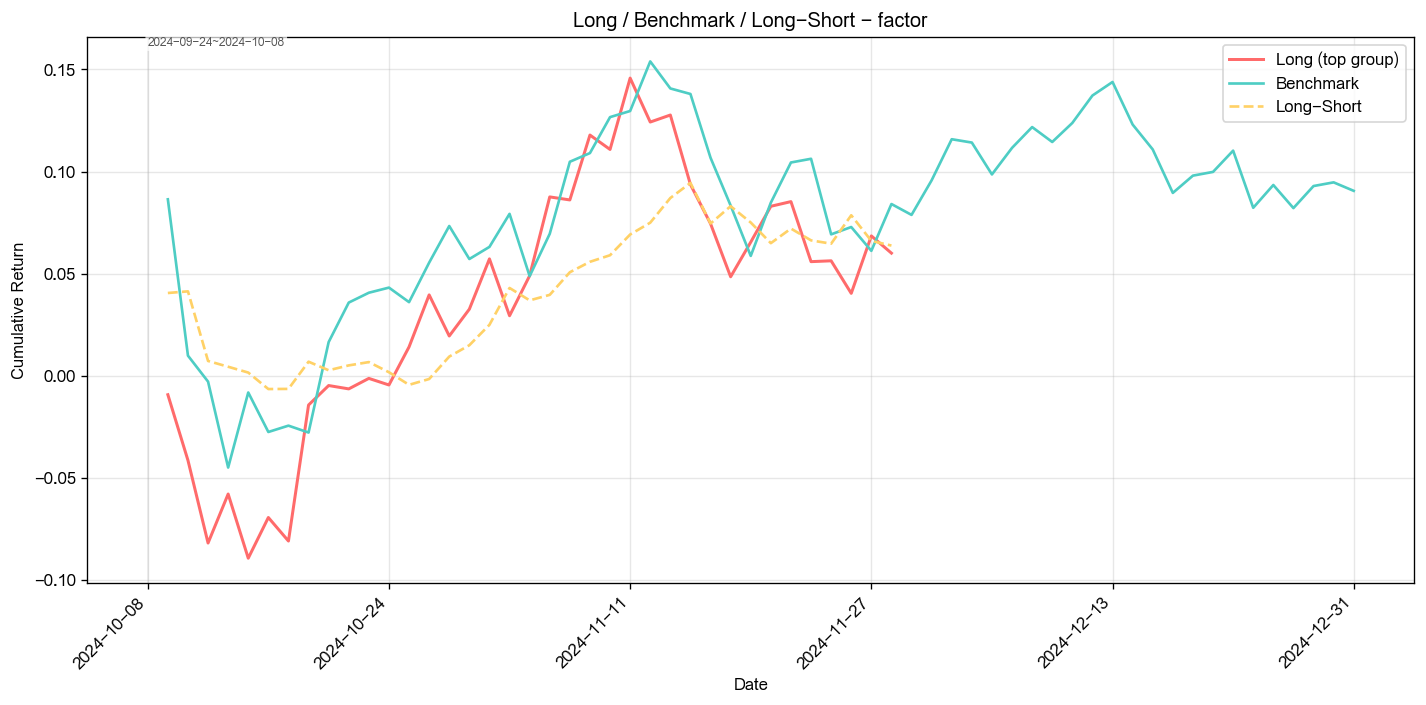
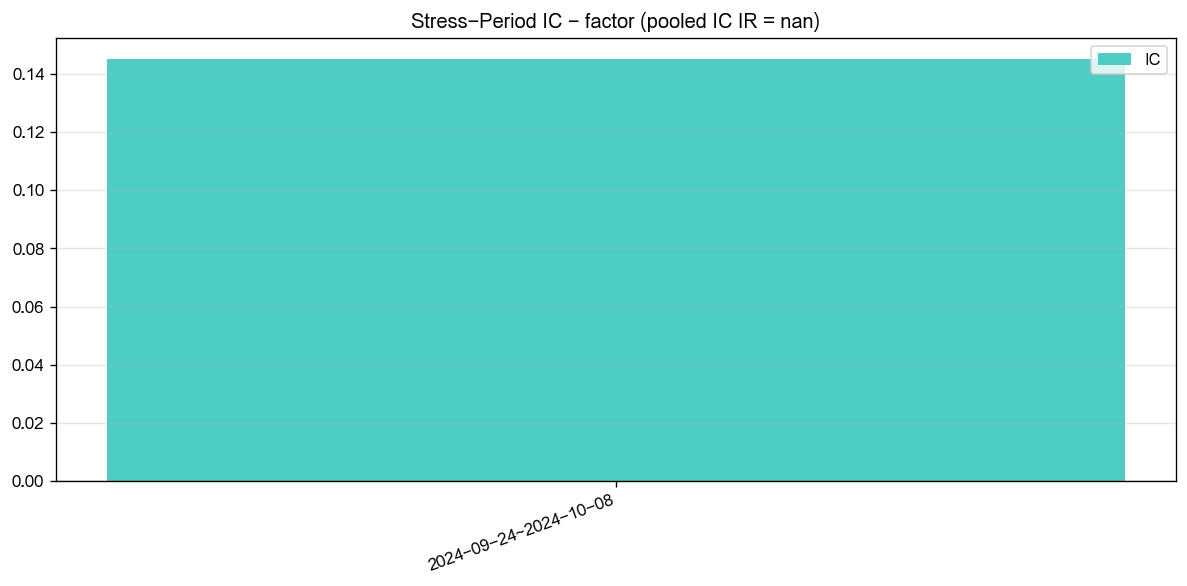
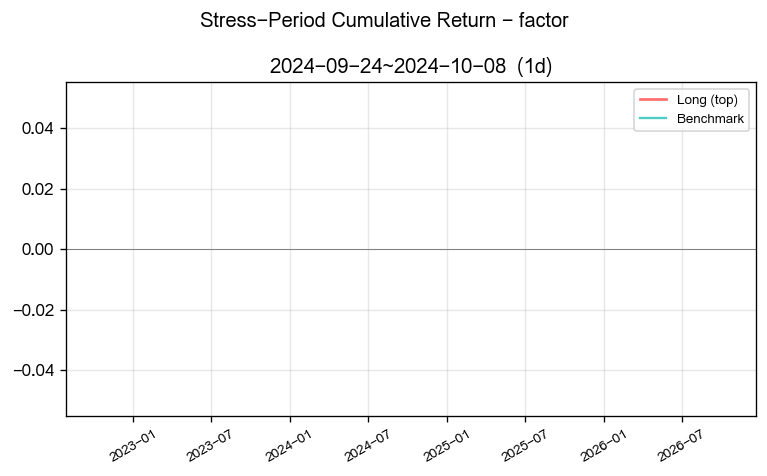

[2026-07-16 15:15:27] [info     ] ========== 因子池回归 ==========
[2026-07-16 15:15:27] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1100 rows=76237 start_date=2024-10-08
[2026-07-16 15:15:28] [info     ] 获取收益率数据, 耗时: 0.8479 秒
[2026-07-16 15:15:28] [info     ] 滚动 Elastic Net 拟合, 耗时: 0.1945 秒
[2026-07-16 15:15:28] [info     ] 统计 回归结果, 耗时: 0.0094 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,kdj_d_9_3_3,8440096.3093,0.0844,0.0000,1.0000
2,kdj_k_9_3_3,5383900.8612,0.0538,0.0000,1.0000
3,bias_20,5122692.7433,0.0512,0.0000,1.0000
4,net_active_buy_amount_main,3326728.7837,0.0333,0.0000,1.0000
5,cci_14,3046551.9998,0.0305,0.0000,1.0000
6,momentum_5,2973768.0984,0.0297,0.0000,1.0000
7,daily_return,2183025.2972,0.0218,0.0000,1.0000
8,atr_14,2062027.2488,0.0206,0.0000,1.0000
9,netflow_amount_main,2057565.7071,0.0206,0.0000,1.0000
10,macd_diff_12_26_9,2053921.8835,0.0205,0.0000,1.0000

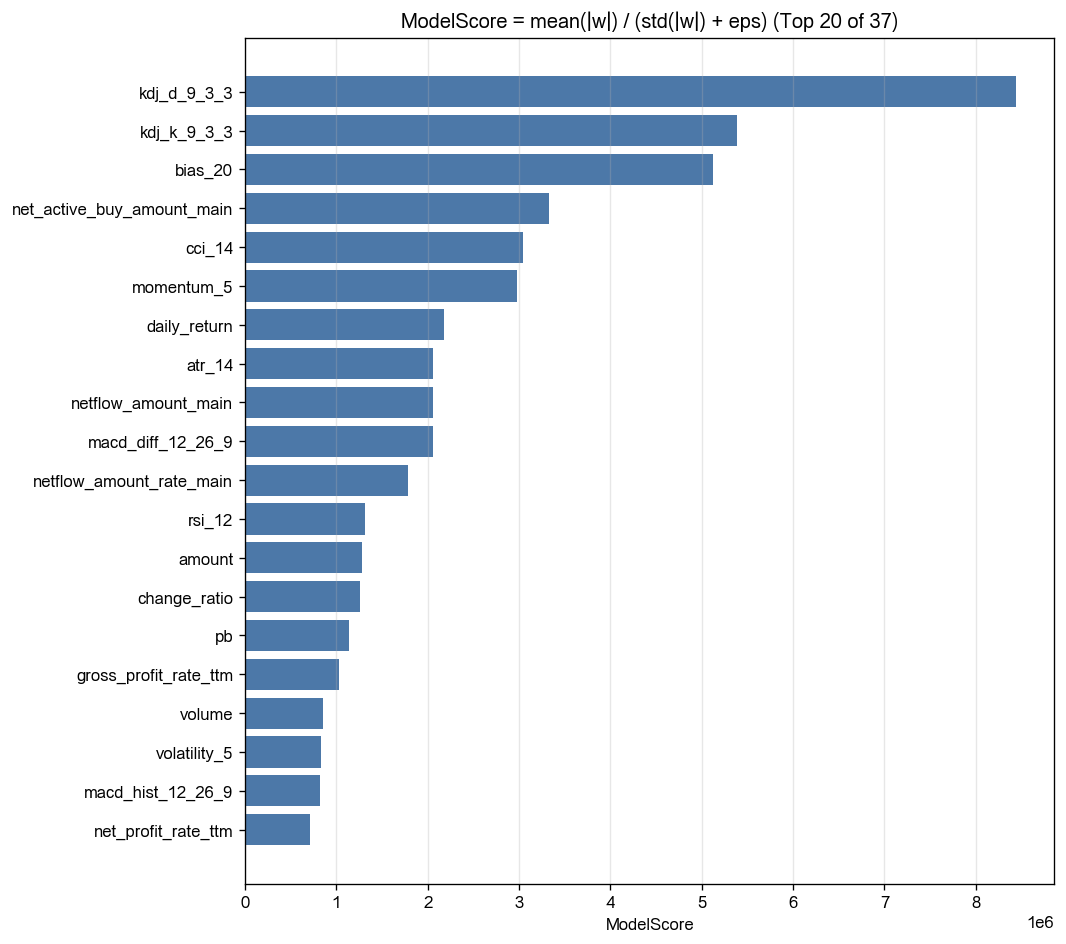
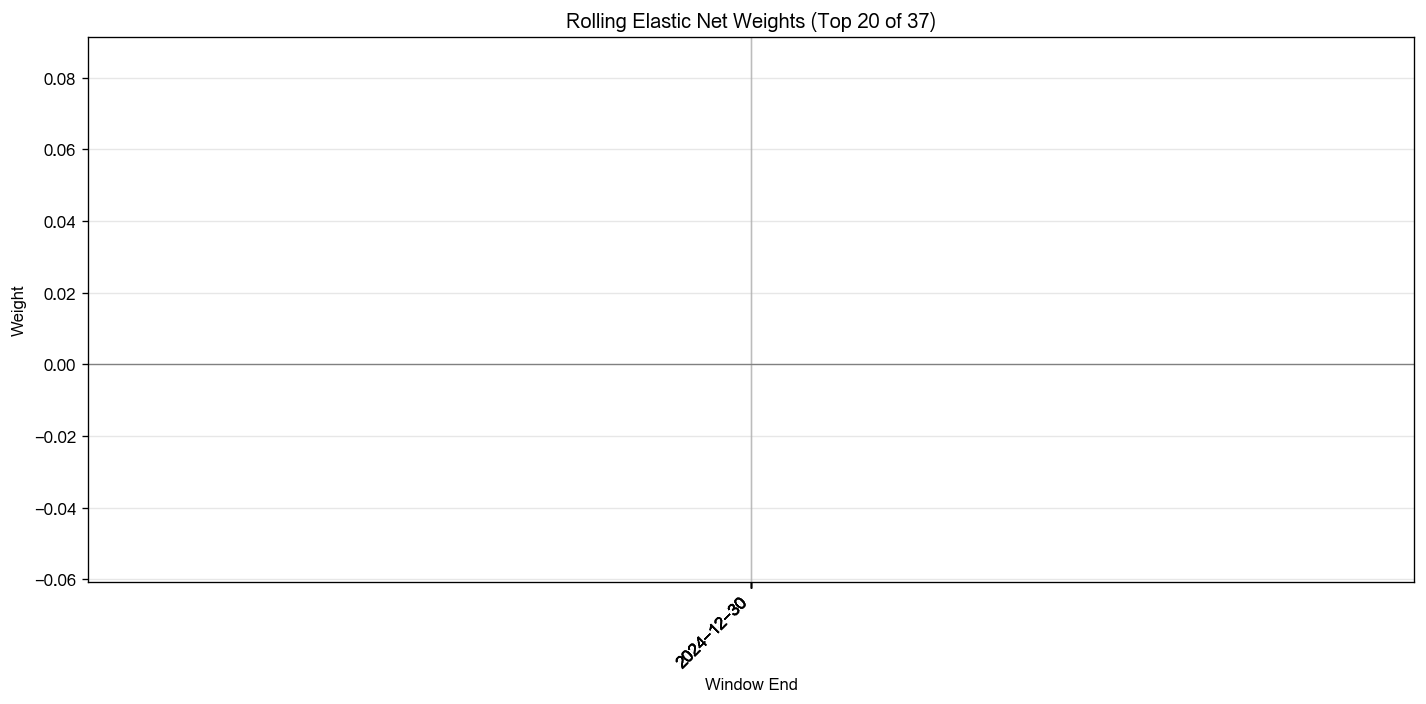
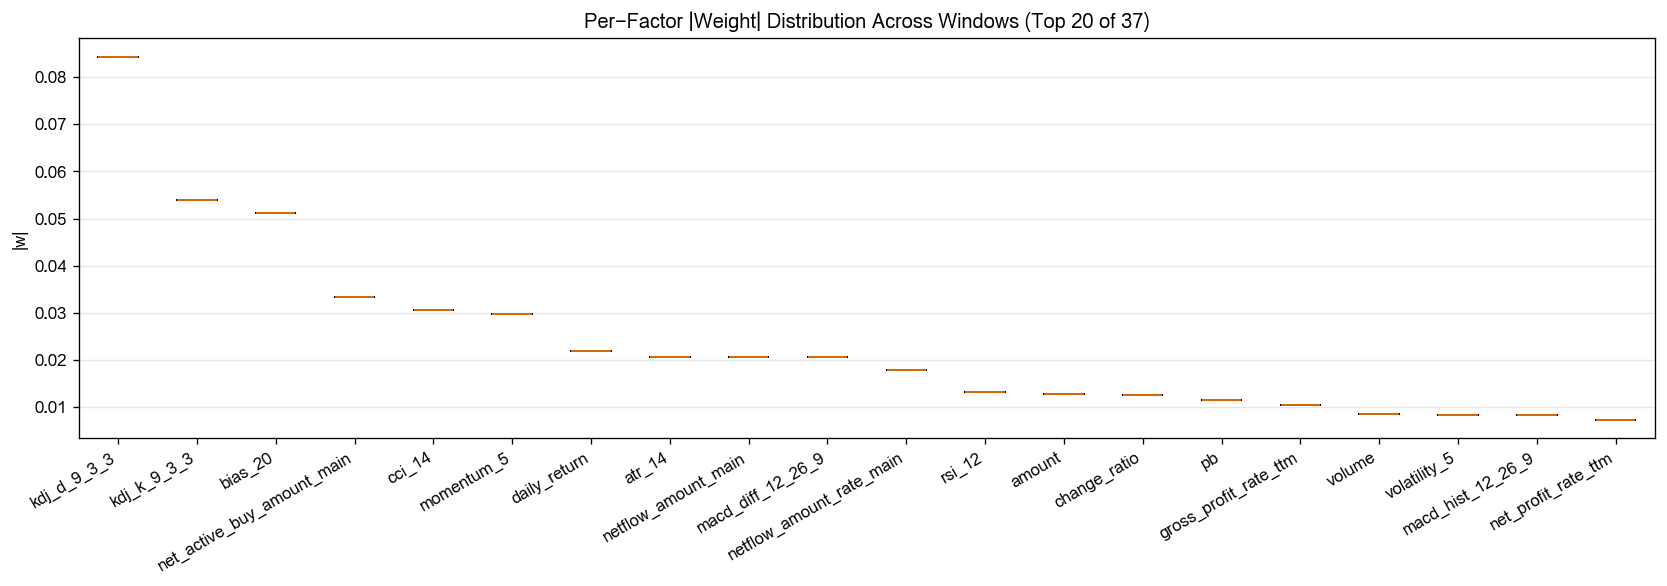
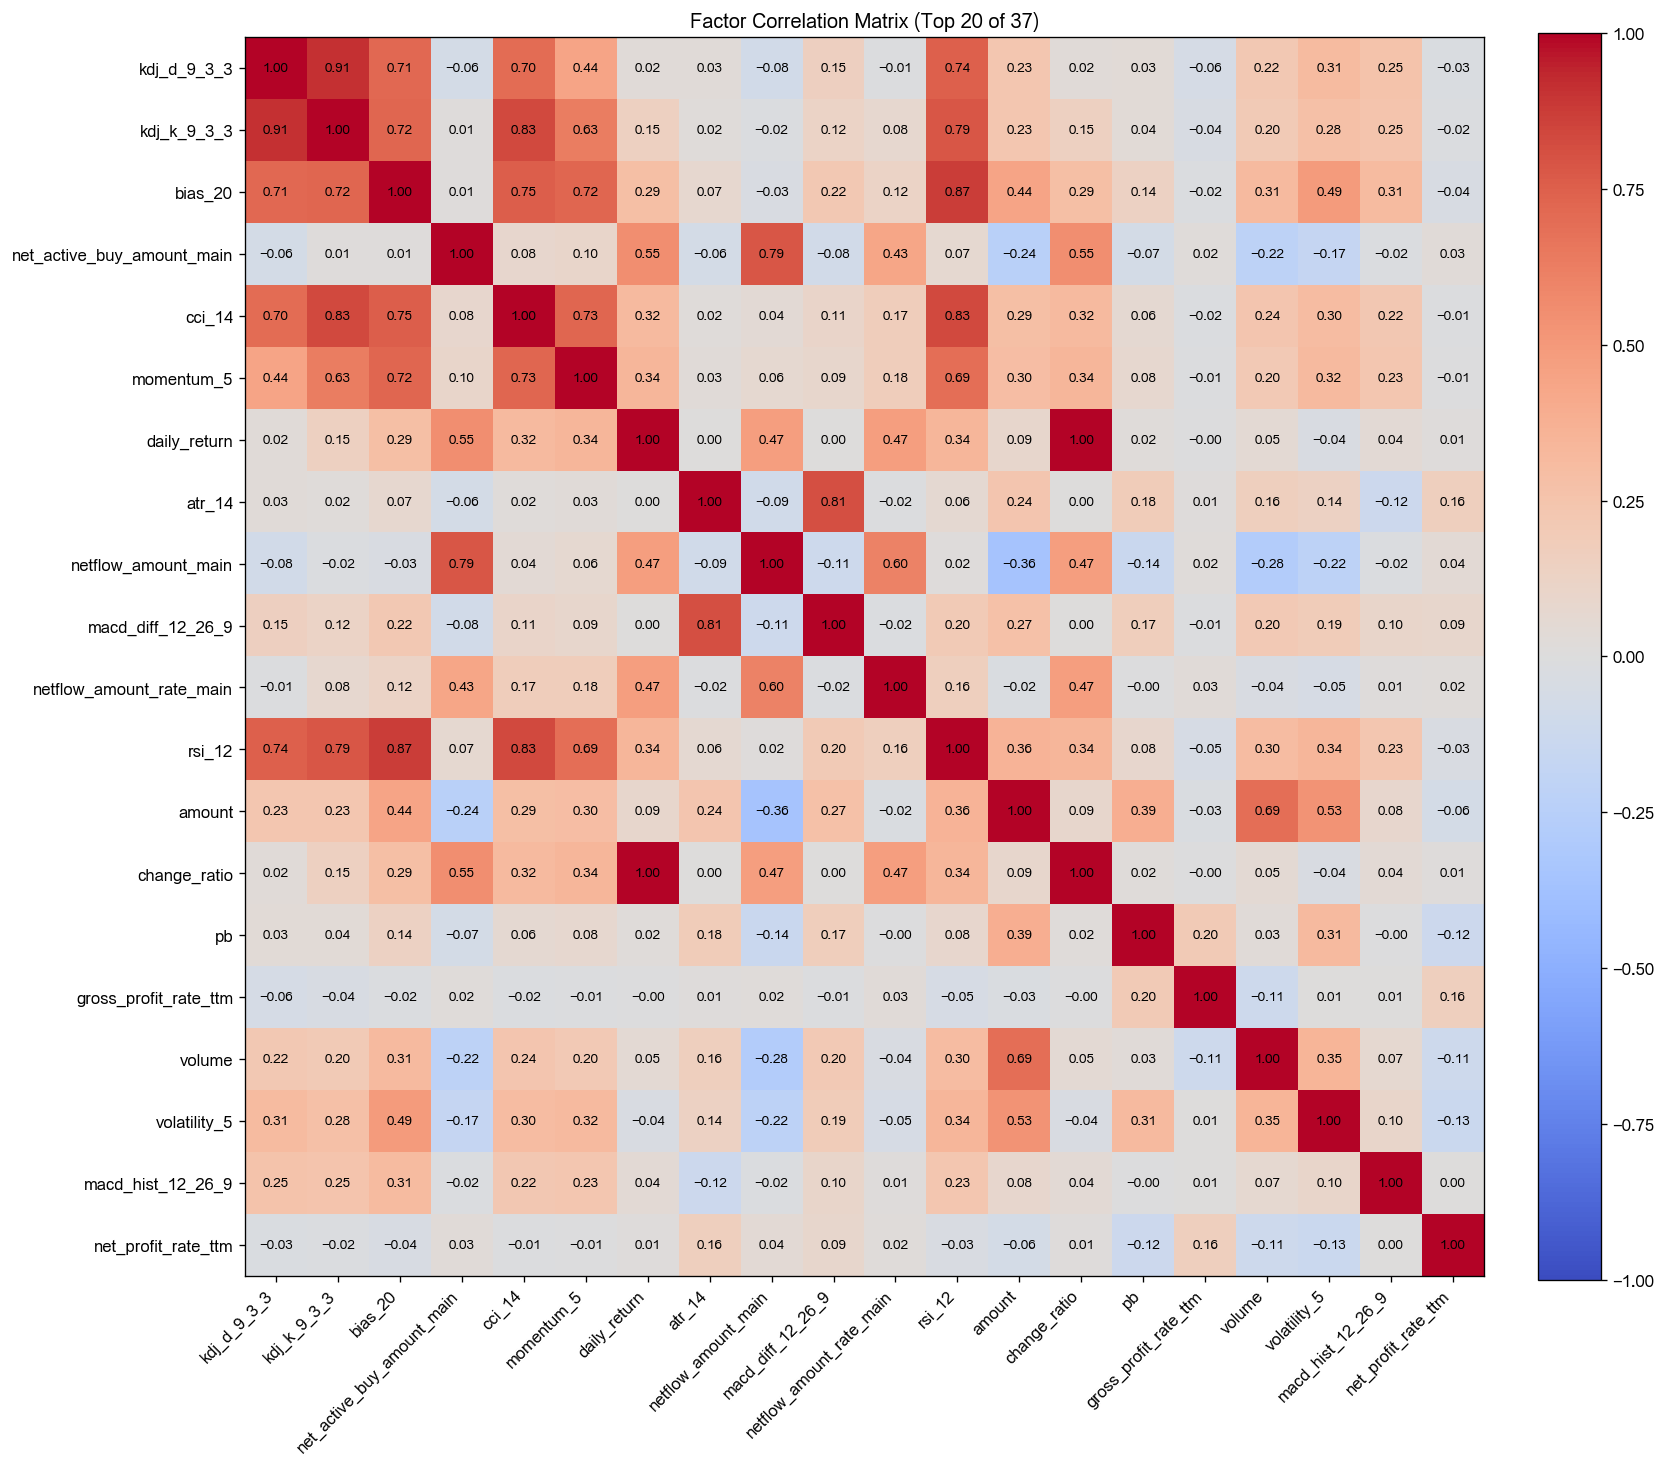

[2026-07-16 15:15:30] [warning  ] 返回的Outputs实例(size=8667265) 大于 64K, 将不会被缓存
[2026-07-16 15:15:30] [info     ] bigalpha_eval.v4 运行完成 [28.189s].


In [13]:
# -*- coding: utf-8 -*-
"""BigAlpha 2026 端到端赛道提交: 时空融合网络 STFN (WaveNet 三频时序塔 + 截面 Transformer)

官方评测调用 main(datasources, start_date, end_date), 返回 date/instrument/score 三列。
- 公榜推理: 加载与本 notebook 同目录的模型文件 bigalpha_stfn_model.json (随 notebook 一并上传)
- 私榜重训: 平台在隔离环境调用 train_and_save(datasources) 从零训练并落盘同名模型文件

模型一律存为 **文本类文件 (JSON)**, 不使用 .pt 等二进制格式 (平台限制只能提交文本文件):
state_dict 里的张量转成 {dtype, shape, data(扁平list)} 结构, 加载时按 dtype/shape 还原,
见 save_model / load_model。

合规声明:
- 输入仅为官方注入表的 26 个原始字段 x 3 个频率 (5m/15m/30m), 唯一字段数 26 << 100 上限
- 预处理仅用 缺失值填充 / log 变换 / StandardScaler (训练期统计), 无任何衍生特征
- 参数量约 1000 万 (10万~1亿 约束内); 回看 5 个交易日 (<<240); 无外部预训练权重
- 模型内 BatchNorm1d(affine=False) 为无参数的截面标准化

已知风险 (提交前建议在平台核验): 训练端价格为原始价, 若云端预测表 close 为复权价,
存在口径漂移; 可对比 stock_bar5m 与 e2e_bar5m 同日数据确认。
"""

import os
import time

import numpy as np
import pandas as pd
import torch
import torch.nn as nn

MODEL_PATH = os.path.join(os.getcwd(), "bigalpha_stfn_model.json")
TRAIN_START, TRAIN_END = "2019-01-01", "2023-12-31 23:59:59"
VALID_START = "2024-01-01"

FIELDS = (
    ["open", "high", "low", "close", "volume", "amount", "adjust_factor", "deal_number"]
    + [f"{s}_price{i}" for s in ("ask", "bid") for i in (1, 2, 3)]
    + [f"{s}_volume{i}" for s in ("ask", "bid") for i in (1, 2, 3)]
    + [f"{s}_num_orders{i}" for s in ("ask", "bid") for i in (1, 2, 3)]
)
PRICE_FIELDS = set(
    ["open", "high", "low", "close"] + [f"{s}_price{i}" for s in ("ask", "bid") for i in (1, 2, 3)]
)
FREQ_BARS = {"bar5m": 48, "bar15m": 16, "bar30m": 8}
WINDOW_DAYS = 5
MODEL_CFG = {"tower_channels": 192, "tower_layers": 8, "d_model": 384,
             "n_heads": 8, "ffn_dim": 1536, "n_layers": 4, "dropout": 0.1}
TRAIN_CFG = {"lr": 2e-4, "weight_decay": 0.01, "epochs": 40, "patience": 5,
             "grad_clip": 1.0, "mse_weight": 0.1, "label_clip": 5.0, "seed": 2026}


def _logger():
    try:
        import structlog
        return structlog.get_logger()
    except Exception:
        class _Log:
            def info(self, *a, **k): print(*a, k if k else "")
            def warning(self, *a, **k): print(*a, k if k else "")
        return _Log()


# ===========================================================================
# 数据获取与规范化
# ===========================================================================
# e2e 匿名 instrument_id -> 真实股票代码 的映射 (zlib+base64 压缩的 JSON dict)。
# 本地由收益序列匹配反推 (1889/2074 个 id, 日截面覆盖率约 99%); 官方数据对齐文档的
# to_canonical 模板自带 id_to_code 参数, 属预期用法。评测器/股票池/因子库均以真实
# 代码为键, 因此查到 e2e 匿名表时必须经此映射输出真实代码, 否则整日全缺。
_ID_TO_CODE_B64 = "eNpNnUuyBC1uRvfyjx0OkHh6BZ73zFtx9N6bquIc7lRFUiQo9fwk/v+fWsr453/+KSVy7f/+1//981+HVMsl7ZSUkIak/SO1EpBiQHKuvHO16lzZIS1J65KiQmoBqUviwfDBxj+G/9jmJWWB1FlEuoiekHyhwajmqNEgTUksormIwSKaixi8UPeFfssqf1Y6+cPuH05m784+mWq8qdj64davCqlJYvHDxW9GTUdtpl9M/xtTSpVQ7tL3ksJEq0niwFaXxNssH6wsak9J9226jFTjnmGvRdKC5LIyIPmPmZCGpA7JReSAtCWxiHARMFJP/xFG6ulrw0g9faHeIPmPnUWk/9hZRPMdO+/YXERnXTJlHRWSrz1YhHxaYcrenf5yYC8Omuxgd7smU/U3imXJbnWxEbJbXTwou1U4sA83YjNqOmqzz48DYcq++Mco/KMcFzBhl+MCadY3bx2Vd1R0BdKsy4QRd65RnCs6pC3pLnXIhJF3U6vLQuSNP6QGaUlidnkwEHkjXCnybSjMArYcsuVdaHlMf9iYQY/EGuTKgLmGzHUl+JnKnYG3RnskplIGBmJxKAMDDhxyYAzWrlgMWHDIggELDlkwJv+oXAy4csiVAVcOuTJgwSELxr6vGC4LsTimhw+fDvk0Ybchu2WFtB+JB+WtROYN5WfGXemU3RLlOSvvk3DS9GAzKySnh7mmyjORZlNOuoPOW/uH8NZUKyYCaDafg0emx59wxPQUE46Y3cVz1tODTRTe7FsS/+j5JNptDkftyyRTedCuluopBQ2xFOGNfVi+YsOIWIrdhnBevk9DOC/f5+haSCyrbUZ5/B0BtMuQNCGxgx2+2cqRXhmliOhwxI5HYpRWROe1tyKiI5Man0Hn9FUZHZnhSXe+Cz/XgSHAkPHdz/zQJDFz71IKg6akCmlJapfkFozv0XxJIWlCapJYw1vW94U/JD/p0Znej2IMSPlITK8+H4PplZwDvansGZNXVOmPySvmGxWQtiT+0KMZ3y/gS3IHF9P7zY3FK77TWQMSzD04wuGgzXNaj2PznFJybJY1XMNmWYN9uF/vmb1KYaF+vbNwiDMlMbvidVYenD5Y2cC5JTHXcq7KXArhGbzidl3B4tX5MzhX5fJMFqFcnnmP7PhFkhKS02eDBKPOxoNarBNGrX7RE6486l8So/zI57g7Uf2i52B6eXeOBckXggersm1O/lEVP+eA5BZOFqFCn/BgVaHPxT+ql+fiQb+NVVjELJJY/aySmEv9ugpzyRMLnjg/SuKF5IkFm1RNw1V5R9nkaIVLkk1W8OD2QdikyhMLaTqHlLuGKK4hByT/EGEZCr2FaAxNytUue4VCbzXm0q9ZnQe1Fle/7xNKuIUcDDXg6h2Sr9gnJF8Iq0/1ugZ/qKJZ8GDIg2vwh/keZG9UuQspG/n+cEHy+BG8oQBdk+n1hxacGnLqWizeN0RYhtp7ISxDPbUWy9JAWUjL0KZcm/cZvM+GnUN23oi4kEk2XBmua8OVIVfuyvvoIm/k2VHykhglV26EV+wt6X4tqfDaCK9UUm2YN2XenR2SS80FiQPaMG/KvBu9nkq9jSBM9fpuzKXNurE+/BY3ojEVjRvRmIrGDcOlDLfhrpS7Nuo5VbwbOZjKwQ0rpay0EXqp0NvwUspLezGXinfDXil7baRlKi037JWPl2CvVBnvzWmojDcqO1XGG5Wd403PC2E4H6eZf0QbHxIPInkPiaUieQ+JuaZzwb25hiQeXD4I9xo8PCRGbUchLltxLsSlwcO44aMy0LyHcrerIc4OianCqWAcY21R0KktnQt51uClKIillq4UsdTSuSbL8g1RvK05O5aeocP4xeg+pO4o+KZ1F49Yav09yLK6y4KV2nAR8E2Dbw6JuWCSqIUdJAR4SCwC4RUVJmkySa1sF0rikPhH5FlUVGrbj8T02+mD6bfTY3kZBYyKpOrFpSJwjAIeEg9WH0TgGPKLigLV648K4xynStKE5IMoQqOAh8Q/ouKC0NqovjUnq9cQlQPq7zT4sI2QRcSdyoUGlkt3TwOFMNytYLcGEvuo/Lv2QfD9kBLSkNQhuYZ+t3n4mQXmxggXgW0x4j14N9B41TEyWIS7FXyMI52eDfQjDjZwDKfi0xh4IGcfmH041WalCMtInJKhNEtMS6M5key8J51w89g+h1U/3YeEt4y2HNJd6cw3igcxeSLRZlOxcQMWZw38Ybtel1E0YoLF8Fjg8A+/fBz+tweDeSYcc+PIh8LBDOZREODzDaxtgnOHwr9P/kslsJjZz/sGcI6g5C1ugO1Q7rvfYNfHvoCwPk+N69f/74f0SymMb+BC0oDUJS1IE9Jd0uRw85fW+A7aDmqX9JGql8RUw6mCB4cPfvn3Q/rs3I/E+8H2hAEfT+RPnH0e275gYwnbJTQm307e76haHNUHJLehT0jvwQ1pQRp3EV/X9ZI6JHd58o/hP07mCvdh8YqbV+QM60fL3kEJyakWf5iudPNggxScdB3MFRwrKvVQmGq+QTw3UxJbM9mtn5gd19m8JEYtR+Xlh7rhh+AUo/hgG5BcPKcYxQf7ZaRw53+S90uqkMbd+a+/dkkdknONu65I5xobknNNFpEcWSwe7O7XZl1+UbF5ocFcWRLSlsT0bnSy97EeiX90VzOYyw8h8x5HlkfqkJwrByTnyg0JFk9OKN3obAuSoziOVNxkZxERkhKSi+isyxNKvrP0OHIwvceRnGMm55iLF1IENeTi1XDZCqtazNQ4jFwstFVeejuq3lU197TlfbD5hg3mbX55jd36prh/JDj1a7peEtMrK9tgrilpMpdn3ZAk7S11Mf3uki539fJGLUiu/mrQCZ7hUJJBy0FMVXmuw7vdc+0IF7zUQwkGbQfdz7N7rB2e7wq4Hveku3va4770N+D+I6Ez8J0OpTLIhSYLVW+h7ScG4qFcZuuKyt5YwliSWOh4U7Gj09fpzD6YnW+ge6odXdPlyZtDOc9NnoMbukffJzuqcuswyPBQO3oFO+xQCoNQUX3fF/ymVC/prmqEq9rMLsOT5yCAkNhKC8fzUPi74O8GX+Hwqx8oqOFXj5G1MNQPpTFoOYhlNpY5gqnkjsHBD2XwQBsNj3m0hDQl8Y+e/ODrHeq/gawb2jCDQx0e6kCKjeVGDB5cPnjN+YW5l4NDnR7qxcicQe7yagxyoXz0U4U4doXk2lFPU9E9C3MFc03OAi8tJzbgzOYgpmpOhcKajbVPtNNU+v2yAl+Sf8hXOIfTs6XTLZ2IzamKnCiGrxT7kdhSwr2Hck96aopMrLS5XQOydak0JxtPmDgncnQpDxcfxTXqc2EfLUXYgkm/mdMfKZnb5xBhy61a8OiSIRdyZ2k6LHh0yZAEqpdW/MJW2UrkheW4Fb+bD9pPfONI7PEGTUj834Zj8NnIRB/KksJMsv9mX/aaku4xbEXfRvVuVdzGwtke6b4bU4sfwL6GyiH5IBujHbyvWX/cAfZ4X+uvVhXovuZ5rdVtuOb5Ifk+iwcVdb9g44fE/uGoFpJPrdxPqQai9pgpdybtovZD+n1IbPshNUhbUr8kBFYrjbnWgnRlWO3F6a/AOv6R09+vq/b34DWfj3/kP94Pp6pOWuHDIZHZcFHrSGe/vkwd7w/v51UH+rKVK7E+OdRLwpGtfvQNR7ZOl4X3eVwSFo+ruQBQHco9/IU52OqVWJ9UiKS7zWu7hms8112cvTF7MDtn4TfXKly62yMxVXcNcCkxl1av+v9Ehxl0uTTLW8I9iizVhS4erD642yXBpS347jEGGz5kFjygFle8pwGERhBukYJpP4DYd9ByEFP5CURjVUj3Ftc5SL33Fp033M51dWjq0LdfNOZLclnXfkq994aTl7X6j7NCcq7FXG9rLptmDee6pvPG7GnEZDbWy6HczaqDVRE326Q+289eO4MC56phZG0sArA5h5JS7r6EnwlCZaOyW7smeIab9/sAvqQt6e6UruIhTUisvLFyElOt3a8rdR4P6W5Uup0teW7x3P2UUq+wtcv/xyF1qs7sMl/rPNgcxVah6Q+F57obc8X7Ib3nApKzD2aXRdtgG8aba0FyrsUaOBwcsvM2bh9clcupFi+9/UPOOTzCzXOeVy939oahfkh333UwW+fjbb40btvH04R0vdzU32udg8YqaThWqY92SHf2rhzAGzr77kqv73P2fUpqkPxDPvG+nYuPQk/nvFiB5PSc2JBx+1VXOWTczlf/xab+SNc+3MQbG67VcS/CQROSK72GeT411xG3ejYNB2wTuzwUFppv0IDk7IvZZW9wZhtbrOG45TfU/x2Ev5VPiY7CH85HYvblg8gCnZFDYpQ8OYKtcePHjfUdx2FKWpBY/Mi7Lt2RQ+qQHHXjTTnDudAMuiMNt+x4Dq6+MZdcOW5c92PuS2JdysmBzMD+az+M2hm0iitFMegKHFJCclnXfD6Gu3vDB7uaD6Jslwc7ObOFf9omX6cmfMMJ22QvDoU/VGlOTvHZLzMg+flMJPNSFUxOcWtWzesjH2N+S7oMvsNRfLBb4TkRi3s+Eg/KcD841ZfkKD4W0jGHchevXX9IHRLPLZQd+cGGv7NJ0TTQLpsUDeK1gDxomw8Mo4c4ViEViTgsQFkRHuL/CFsUQFyj/qJAdREFGkDmC3lw0keFRNAAmixWc1DpI1RzXBV/KAGFiVE+4yrcQ2F997VDMOfoPIUAHJRmFITWAANvqGdQ9FOAGA3KKwpIkQG2XTjmAKHupg9wzIVs5QDGLPJyLObhfMc93xA/CYKzku0bYNPFUw7qJQRKDsolCjA50nYVcTALqyGWOamLKIDfJtD1QhhxVlZMCG8CUy5E4iblO+IjL6L//DnTXHP6Az6AMqDcF5/UQ1RssUk5RCUJPVuDMqDcNxcqOTn0yqFP4N0CJSfo7ooTP+8HcCi8Frj3Sm52AnsXNzmpcBA2OQdPufFULlQQHj+B8aXwFIxRYYwJY9ThGGYGdDZBn4uXXNTIVFy1VVgzHteiuK/i2iwOuXLIiy9bfOPiBIMTXNGg3Pda1F4JW1zUWQV28soJ5e7z4vMXs7g4dyGLi3MXsbgoghGeuCjNEoq4qIEJEicL3gh4Y8Eb4hAXnBDpzJfHgsDGghMCTljUPwRw+oXQCITGmuwqsLEFb4hAXNT/BbyxECyBGEEDNHAeixqXgH0WrBGIiA1rBIn8TTmL+MRdmIfU/kZqCEXcsE+Qotiwj9jEfbPAkUiETbmLmMMNQyVO40YkCC/clL8kHuKm+iUpB9iIjYTFNiyWaJiNzkkcqk1dSMJ0Gw2TsNiG6RJ40KZgJmG6DYslDLVhjYQRNkJCTOGmODQREpsiKOGDG+2RIFE3FZ4iBTfnLgTwF6f7omp5d+qYEnvhhzj8Unhqs4cCrwvskuuVAFNXW15dLSWfaY0u79+sK6lsW381bJz1EDcaSI/xKs84yRGvWoyKNRGUsSG51ESmzLBmCc0v1OYTbqQayZIoxO4Uxtv4TKZo3MZcy1qMTvGroZPa0a9bYHdHwRryqB2O1m2jcLO8AswB7ukLerklCODUxedOnhsPUT9B1ItwBm9c1wOlg3B2VZiUgs03cNCYD6YMvlnw/AZ/7md1SKBNBZsTqu4P3gyIKy2t2pSfpMC4QsWXoKIC4Lk9gCiQtybQqFIy0tYDGwK7E35aebC/B3mdHuL8gNj2KQIN9NdwVDDqIauSSpkh7DJB3Q4BlUlZzFiOogJqOn2CP5wopEiAq1bpHRJ4M4yT8z3xoADUBARtSV7gLVhXGSSAB5yVFbxGEWRTyXmUP4gacDfmCgOUUlSRK2Ryw+xaAl34sttFiAAtMVmSJLvS7FMCLcoh7ILUlumFIx4AZ6yHZgAGYVK9AZ9p4oGIbh2+MbFPmszMOxCbYZKFIEgZD22wSQubIOWdR5rVBG1giCUHScbRXyqXhK/J+DFYg3iKAa5k1pfWJIfp9JPc9MyXwyRhKSBgkfFa5qbXjYscUjcN10jDvbwYybr1clk3B/Ewfvuuvj583SYXUw3OlMtJtb/0zI1v1FFMcdxITN0GZ+oi+i4pJrHwRyK8VQ3hJEEjAWItSQEIEGvAfM7oYiSY+GoaJyWKmM2YHnGK3l9gkfjgMhhIOEgIRQN18MmxG5Mi2lRf0Ii4CwF4fH7skk4CD2u0F+Lc+vxXg32KCHHEcQgxigZWgYClgS9Vmq4wXi16fGI0Wnk3MdIq6n8SGLB8bmIC1aFngOkbWtAYsQi0hVFktc7Gm7HcZWP1J2vehAosIdmUBKeVdAW7tlkHVjCv2nztM+gYYtOVihn9p8kGm9QtBEEUh/jgGixi/KnZxv6xuiqxDKf1dg1zX1zPIWH/uIiG8bxeoTVVplYZdqznbcFq5xz2M5JgFYOUtbPS/cqHUfPW2wwKFo3IHIuIAs/+SkopA7WNxKRaoL5yOwpIwjKjRZFEvOIa6lr0hA57U6izX+UJNRiq5tKp1BASX6gpagK4K/ZcV+kG9kEXnh1U0ti4In64z7zQoYuJx4pQXSf1aQ/GnZTgTOsFkiKJKcY/Z8cYELVOzcoUcp+UP83xRmGkaK0llaFzaqRg5s354O5YJM9SoiJqTqencGK+F6JwQn6ORuGpTQKisRNT+HrDJp6i1Ym5PTsMuMgkOkXvhx++6EcB3YZhe0QHFpBqvgBJKyr1im5+8IoK1rE+oC66uaoDgwdDpEtiomQTi7ohaTo1ADhNFdvAeplIO3ZmwdwRXQk2rwlMasC524PrFSCKmnQdY603oYYDyKCQGNJMZTxrCrTXqA+vh8UjUHeAWB8CiCem5tQkmcDlpnC52UBaCTKagIymZusEpTiF6hDk/9lrF0QFSYNqsRMrNILAFK18CCkAWYLCFhALdGguTnZtB3Ea62GD4JKtbbax4LbvszmNvUQCAV/bVhls0DRiLA4rAQ7KZ3U1rC5hOACNugllGDr9Elolx1e0p+KC77KYVQrSa2U8Qwx0gcABMkhF4AAZJL+WliTDH/YIfyHDjCXOQYZr5wPKMOvTgqS25mHDWMt4qW+S9M9YI6ETpjovaDRbvIQy+VBSd8Bk89mxnTzdeAZdJR9qIhoj/wPMMwNHjsytIT6/iTE2oIu5PdUJbGWbfaeqZyPkf8LgS8H2uwifo0GJ2RPXqS8qTJixGislFImCX8TRA1NhkQcJHOhFICsMZJEUsjp4M3Pab6MQfm8GGwrh0jYfiRZr6/W8ohWXnS1i0YNo2vaG2Pm0RQpwkRAzWDmDWPa4YTPPnBpMBJq2S+0YgHu8UVha9uXovLaZxNoJzHlWtRO03nZq6DTt2a97B/GNajRoYuXUeMEnumS8TgCB9WUvrkWhuWmEs6mYWq+OmX/MF3/iHw3G1k2BrZHWT3YQG80KWCpN80WNaLhiB7/4Qfa+Npr1mxiKNkyKiiWnaRqV1XetnMAMkU0iKLDtlh8GQSkblUWw+m6ZdFDk/0qNg5jXsCg2KFF/BYHBC41nYWKQGTr9ROwxFLUKqSKdVmEnc01rCRtFxNPiyUY9pXHSaFQMW84QjRpyHYxo7ITY/k9jyB/J6Ait0c77ODvstdybhsW8isuiAcLDfAcmTIhjTvD3YaCqUZHWtgEhjLn+Qijgdadho0lkB6fgmL2ggcdTyUB//cMN8rKI1yiDEIcgogp+9uEb6g0lVKdvFOt9mEllS9Sjq2xBVBRhN0FYwurDo+hQpH+AZgQvfLChedKwRK9AugRGdNR7F/HSQc/0LvAL1W0E7ag/4ED1AX0ADQm6oozimMUPUAN6RhNmMmqpNyfgnK02Bzb/MYJ+pIEmK7DSIPlUqgl9xgxz30Qoivlf4hpm9EgV2Idm0doyTHQV8oDbpBppG7yUTXcw23Fs8on5+omyoPbaQAaarb7ml3RgzNeKkj6N7TUeJEPzsipoNh3G2kiOKAdqowGaH29t4DfWiyEw/bYdS6eF3DaO0cmrbuMrnUVsFXoHsrGfeqVd4F7OhRIWO3NIPLjfgyjO13EKWScEo056nIzXN4hIg7bBWvSSMSRfKavvlpNXIiBdlfWDAuffSvEglj/6SzugGnSTE20x1QNJqf20MUEjE2HtWzRSTlagfNriQlJ2U+6/mpKalkBLTd1ox7L6I3VIlrXfeGS8emk8bJMAdVLuq88FlvoX47mFqSQULIpKHNLUNW/4TvlqDvEY25/6O9SAxeW9UcSmhO/U4/ZtvRMe9tCnA672y8hcH5UiJWIPk7f+hlKuw4h7OHUPKSwSMpebZMHWWd/MDiO1QqlAimgsV33Uhy4ti2IIY8yV6o71PDq0gBXhjTrbDAGGFNVm6B1SvppWCbeGfE+1QCNMb2yjUciZ7WF9mauJX+yE6Xs8vQNAV/+GRErOhzkFHLueY4TC2lUfq4Ed1LFct1ygv4zCuqfRq77tuifb68MA/tzP4wT42vv3Qh9Sl9Qhsfe7Msp1/aAZX9KSNCBtSfOS3JxbrHRIwlD3Yi6xlj8kwSFZjdB/nYQ+JLzu/msI9CFxHD34R1NyVGCqI8m62/lvEgyvZgxw0epSj+I1kg8msNIEMqEZglT6Rvmlyo+0h3HdWvDE2uvyTFu48hoz06JYZ5PimaPnDLuDo7A2slKHEJaZ1UaKYu0HKNj0/lQRBZH4hyegG2h7ziAk2y92zIK9nmJF19qurIOG2OrtfpGG+acB6E0j5OvaOQEZlPX8Q1rt2WlzovrEytVNcxXRPB+cKA5cMcdP/yUD6kTP23zJezryGE9ftJhRFdJYx2xWJOpr5otk48YYYW+s0zrEaLR3WfZyaSTl12vdQke7paPZcEfXeKOYy6B7wwlbquiOx7XMSHR8KYNl0XGALbxJCttKqa+lCV1H5usnQlDakGelyraqrQASYyVmUlFrDU+SI9e6yCTCamnMx/ynpFwVSpOTPt8oEvBGpAftMfQDclKpOvXwJi84jUjvTmGliPxyYef1aaZy60vr+FM21ymbUxcCkC/xqqKowjKOmNQTVD2PBGNuUL81wOkZT8tdUquvyIXQIljxTtGBRkjDLslX+zgpmVjWDkzKCbbuHPXHuR9u/25Efypn3kLs/ir15g0ZH5Ia7SryXp6SuxUZ/RWtUUrc69Oh18jpL4RLDLy/mqp1ubmnS12LUbqGP2zjV2GqHX9ghI/eU8kF2lH/9EbKPyQ1bUcVuqt7onzFAfw6Dn5JjloThVlUmHd6s0H91xvvQ+qq1YYOHY7qkDjH/rut4kNaPsi66n6ku/p4i5gTklp7M0pFXjEKwkXcMtMPiel/OKoPaUrq1yiwYq8HZkjCq4e0ITkqsRPWIy1IWhONueCvha9s5HHjgtp5c4MlSBuj0m7QRoK14DTanq8WnMb2EIhcc9HXuyiAwLBKkfZiMf506ad9vPhJeo7EfLFigKgrX6yY5uc2lr4GUxZT3eNCEVLhfEj7kkzdDxReMbI60FuCmiKIhj7lGaTNx8vmkou2c3t0muxt3cGOKjPGHJ008MaUOz7cb1Q12hJ0H69CTYLG4tUykKCxeH2rHzfVXW3EHfhBNttPujqKGU3gREWJl4VWMuV1s8IV0zBOaoWLoj+BE/361l6fFLVY1Z1Q1KY4deqCbEH7HPPHjUxni5duxSN9PTk6KDQdRMpEFsjPnIDJLC3LRa54PRIh1P1aBNA2Y78Sd5onjNcQ4PqazxksF0tWX3ixXKe4vgxcoePBqxgtd2tqV03W6/nVVxdXG8FR60orPQL2K9um+vT5O0l2rU6DkNQG9/pIlJqqvnFl2kuuFUrSni4lbzYs9LqqNKxuWzfl11+x8LoOcFdstpvv/Th06ic8rpdq/Um7D6mr2BpazGrX2wzi4+NJ2uinouapkELNU3H72L9+Gwl89ACjbqO5I6hxbXtF85hZPV4Oo95cm1HPhexXzej398Ad7UWdwoNWAvfEEOgq3MRpNTrQE2e6h6PQwbZP6rfJ1yEtRw1I6jrad/GZ94YrPVFrk1SmQO1FaDmEwxeym/arrYUAaVOeF7KUzZRkBeglALpWKk/enQa0gzzSUmUEAF+IUKW/SwjYqaOiZ95VC4GbqIKaIMjLfD4hrdztDFoIo6ZYnILL5LVcUUhltZfdoi18F7EVeI7d9FOAZhrP/aL76VKzNXBK67XK7Ggj8dWjo1T07rhOoloE+LlRBpI6Cz/06bobkq3ehhBj8dxyqo2u8xW53eFz6pJQf/rL8/aTrxbkxRyQjAvPixev9toP+vZXmTCDplcapxlAXOwEk3RznXBXJv2zNB6TavFiTifJ6fyC2pcESEiI00C9jiZSGkTysD/doLvOMEw7QNAM46GTBmHLBmGLZOCyGdeigZYgilzAopcI+AXye4tnWmDbbaeSCxNi50NKX828BU/vK+mrTlPuTROeP5oSfZrGbhlln63GFVWL76BF4q6q3BpF8qmWapuOD69hAW01+mtF0OiHMF5pcyV31vX4Eiew6PFdkh1F27rh1v76/qwbeO5dt3PdMETvJhYx54xntY1/9Jqz7IkSJHjQC3LeJii9ElqNp39w5ZIocL9o5WrNzNEdeCYElPvd5o+zkqqMuwZjGv3XjuuQxlNS67o0A6Xer9l3SIDPe2N6QxO9oefl8P5zH76ku1sgwZUQAwSJzb4GoGLvqZlUkr6LV65P9esceVEzl/Lu+wPs8y4US67Tsat/AzNjkr42gpZL7HMnSroFOlOCnu9Kn83lGVlfJ36iirbi7gAYlrK0k1DbZs+4racWXRy6F7yu0ZRdjSdvr16rVQTrvADZGgbm5ka4WoM0EedhC2+6sAknXnfl1Qra4GaT6s0Z1MSVaRIJuVCMY2SlDOZ1CKNBk8Dxj/lLfu21TiVzJs41abmWpqgaUropDWkjUaaBR+Bpx+0SQIG/MW37NoGFrvqkNFjLfD3QBnUjL6BXcDiESyAz10M90LhCr64FfWxsW9ySnhR1Wv4BCtBmwMcVI5OVtsnBlcgXcSH+IeK3Fz7w2hRFBDtiGnFZ1+5N9NUxhe+oRuyxJ0Erk1v95uE+godRjbyS2rY3vAk7sfSGn2Cjst6Yy1Yp/QKKD4kT6o1wlL1M+u0G+yH5jwhSIve98YpTEdmQh3ZG6w03YT5De9/3EaTb78dZvVSEoMg5copTwEOY0iBKEl5NNoAjltdPAZGJqJvcUVcFKBLL8SqcTQrnXcdSuB3O/MbxYok6GSkqRKvan2gVpHcXKTXn3etLKkmy/qpjSUDNV6tKpfXWtehEnfa7EoqIT32IhmuTfi7JNDvDdQ/eMJCUZrye8Y0LDGz+GY0rZ5Y3HzTqCtaznjdmtxi/iXFexxPKFRFcFZwVwTkUnMhb40Jc2lSFIwaXNtWwuIG7iqoV7rEw9EXjBNcQnR33H5Hw4hjpufZiWvsmcaq3xMS+rky10jsLYILyertjPReB5WTBpn0v6VBXwvJEcBZe1Jj0rCtRX8txOnSLs0isYhujJemMTz7eMkqCUy+LQ8isazsPdNHIZ+aT2DFktljEekh20G8mtD+IZRI7os/RA68ZEs3xq0D5FgR4vDagUZyaz0htBItiPeMZknqgk2dpr0cT/cXma0RE6d6ar/URCRqTF5Qt5DbrMWnltAVMTNp9bXMQVBH0fHl8YuqlmZYgVFNs5bQniZCXQZmM2gITNlqsvnwGFYOI899NQl8TW6ubP6xD7YeVWodBJUI8du3vBf1Rt3+ItrDTfq+EeCLNXRQyHKkFX3kw1beVdIbqqZIRsu99v3c9fEhOjyUemAb9d/fxV1HrDqz72kJK+6+K6BuN0va/KsvL0vqV/dWeIBTS1UAs9oYTodFEWUEhmAzc+wmtPlCPyCyAAdUK/kGXBAOaA7yd904u2oR4td5CoXir3QIc4V1uG9fgXQsG97R3NS+dCMTXE/Ka7ypTWqTsdyckUZ1a3y2BINTfJXekHeytEpWbYpq2ewByezfyJACHsV/ZGvhng0bUWQzvy2JZn1vDtflRS2KWV2Dii5cDOF+tYQ1u6KsCQoMb+qrNWQIFfQ60q0zQL1bT7Xv5Us3lZSxkJ+q7yYM4j0n74PaFut9FESQ6XiE9wZlWXm19QymItMOF0NHPDn5NMzY77oiQ6E/vRPqwP0eDbL81Y5PGA9NqfvLev4LBW/qFh2KV2uId7WqXG0X7suMFTICf+yEtWh3bIZke3ny3rdBG+TUPrJVGvaYZKkmSV8TDdS91Swr6CRrfaNFxY/R/EpXjJSptElD5iwBDTRhZ2ki0shXR5H9rN3FMkN+K+H57K3+ktqMWArMoaRH3oY1/y8g+MlRJS+zcuqseiHvbQPQgA5IYGP1Wln1iMUUS0y8fJH6SLvXe2/LJNPhgQ5Dj2vYgriOP93tJyyGpTe4FJh+/TNIgRWHEJjehntTjCvyyJ97RAdjU4LyqNy/2W/RdE3e+L8YY6aE63bj8wGWwkHqCYvM63UlJU0WsTO7VtiZogeHzptZFRb9Xli7qjQKPZRH4CcLqC0x2YN4vXK1ASHOfZKv2TyK9b8ucQpe19ucqePDr1oz3AO7tRekDaFcRGDDAhJV3Oy5+j4VudZJbr+8SVUDh/iGOwyeJIyicmqh3BSAKzTeMAijcVkuffm0UGkmiuNkIUhL7GmYbkjojr6OPpLxquoZN6ClfGv1WNlXv0IyN9kpdr0224XXg4abN+trt7Jucqe9uv4326q/Imn80c5XcaFktp8+CAjChe4QwUSsdH27WsbApG891VRWVl7++Q9czoUr5obaZfZpt2FzJs5/i6NT4vJsJaE9f1Kp7MEqQ28UXfbxe1Qvd4h+Y7Bq+n/y31bP4HHblaSjazNc1larU9XBim4D9g2jRDYRQTSNx0V//4k0gqKheNoEgL0drm+iNvc17QcTV9kJimPvN5DN6qbbnJ+BNvLA+iWxxBr0i2QUV9ErCOFPXAdiTnVp6RRpbY9+DFEGq9oLAWeoU3DKEj/x/pITkXCy1UQnW741cHz/h5bYJ6InQCqJd9iLqSUDP4uyeQK29nag38ve2EOoNyJmFU/0qgWckktONUm1NSkoAMTxBV1ek7qLviPG9DQ7qBuj//R8v/3c/"
_ID_TO_CODE = None


def _id_to_code():
    global _ID_TO_CODE
    if _ID_TO_CODE is None:
        import base64
        import json
        import zlib
        _ID_TO_CODE = json.loads(zlib.decompress(base64.b64decode(_ID_TO_CODE_B64)))
    return _ID_TO_CODE


def _pick_tables(datasources):
    """逻辑名优先; 缺失时按公榜物理表名回退"""
    out = {}
    for freq in FREQ_BARS:
        if freq in datasources:
            out[freq] = datasources[freq]
        else:
            base = datasources.get("bar5m", "bigalpha_2026_stock_bar5m")
            prefix = base.rsplit("bar", 1)[0]          # 保留 e2e/stock 前缀
            out[freq] = f"{prefix}{freq}"
    return out


def _bar_slots(bars_per_day):
    step = 240 // bars_per_day
    am = pd.timedelta_range(start=f"{step}min", end="120min", freq=f"{step}min")
    return [pd.Timedelta(hours=9, minutes=30) + t for t in am] + \
           [pd.Timedelta(hours=13) + t for t in am]


def _query_canonical(table, start, end):
    """查询单表并统一为训练口径: instrument 字符串 / 价格元 / 缺失 NaN / 26 字段齐全"""
    import dai
    sample = dai.query(f"SELECT * FROM {table} LIMIT 1",
                       filters={"date": [start, end]}).df()
    cols = set(sample.columns)
    is_local = "instrument_id" in cols
    want = ["date", "instrument_id" if is_local else "instrument"]
    rename = {}
    for f in FIELDS:
        if f in cols:
            want.append(f)
        elif f == "deal_number" and "num_trades" in cols:
            want.append("num_trades"); rename["num_trades"] = "deal_number"
    df = dai.query(f"SELECT {', '.join(want)} FROM {table}",
                   filters={"date": [start, end]}, compression=True).df()
    df = df.rename(columns=rename)
    # 键类型统一: compression=True 会把 instrument 变 category, date 可能非 ns 精度,
    # 后续与股票池 merge 依赖两侧键完全一致, 此处一律归一
    df["date"] = pd.to_datetime(df["date"])
    if is_local:
        # 匿名 id -> 真实代码 (无映射的 id 剔除, 保留约99%日截面)
        df["instrument"] = df["instrument_id"].astype("int64").astype(str).map(_id_to_code())
        df = df.dropna(subset=["instrument"])
    else:
        df["instrument"] = df["instrument"].astype(str)
    if is_local:
        for f in FIELDS:
            if f in df.columns and f in PRICE_FIELDS.union({"amount"}):
                v = df[f].astype("float64")
                df[f] = np.where(v > 0, v / 100.0, np.nan) if f in PRICE_FIELDS else v / 100.0
    for f in FIELDS:
        if f not in df.columns:
            df[f] = 1.0 if f == "adjust_factor" else np.nan
    return df[["date", "instrument"] + FIELDS]


def _transform(x, field):
    x = np.asarray(x, dtype="float64")
    if field in PRICE_FIELDS or field == "adjust_factor":
        return np.log(np.where(x > 0, x, np.nan))
    return np.log1p(np.where(x >= 0, x, np.nan))


def _build_tensor(raw_by_freq):
    """
    原始行 -> 对齐张量
    返回: days(排序日期), insts(排序代码), tensors[freq]=[n_days,n_ids,bars,F] float16,
          close_adj [n_days, n_ids] (后复权收盘, 训练标签用)
    """
    base = raw_by_freq["bar30m"]
    day_all = base["date"].dt.normalize()
    days = np.sort(day_all.unique())
    insts = np.sort(base["instrument"].unique())
    day_index, inst_index = pd.Index(days), pd.Index(insts)

    tensors = {}
    for freq, bars in FREQ_BARS.items():
        df = raw_by_freq[freq]
        day = df["date"].dt.normalize()
        di = day_index.get_indexer(day)
        si = pd.Index(_bar_slots(bars)).get_indexer(df["date"] - day)
        ii = inst_index.get_indexer(df["instrument"])
        ok = (di >= 0) & (si >= 0) & (ii >= 0)
        arr = np.full((len(days), len(insts), bars, len(FIELDS)), np.nan, dtype="float16")
        sub = df[ok]
        for j, f in enumerate(FIELDS):
            arr[di[ok], ii[ok], si[ok], j] = _transform(sub[f].to_numpy(), f).astype("float16")
        tensors[freq] = arr

    df = base[base["close"].notna()].copy()
    df["day"] = df["date"].dt.normalize()
    last = df.sort_values("date").groupby(["instrument", "day"], sort=False).tail(1)
    close = np.full((len(days), len(insts)), np.nan)
    di = day_index.get_indexer(last["day"]); ii = inst_index.get_indexer(last["instrument"])
    ok = (di >= 0) & (ii >= 0)
    af = last["adjust_factor"].fillna(1.0).to_numpy()
    close[di[ok], ii[ok]] = (last["close"].to_numpy() * af)[ok]
    return days, insts, tensors, close


def _norm_stats(tensors):
    """训练期 StandardScaler 统计 (per-freq per-field)"""
    norm = {}
    for freq, arr in tensors.items():
        flat = arr.reshape(-1, len(FIELDS)).astype("float32")
        mean = np.nanmean(flat, axis=0)
        std = np.nanstd(flat, axis=0)
        norm[freq] = {"mean": np.where(np.isfinite(mean), mean, 0.0).tolist(),
                      "std": np.where(std > 1e-6, std, 1.0).tolist()}
    return norm


def _day_batch(tensors, norm, t, alive_idx):
    xs = {}
    for freq, bars in FREQ_BARS.items():
        raw = tensors[freq][t - WINDOW_DAYS + 1: t + 1, alive_idx]
        x = np.asarray(raw, dtype="float32").transpose(1, 0, 2, 3).reshape(len(alive_idx), WINDOW_DAYS * bars, -1)
        s = norm[freq]
        x = (x - np.asarray(s["mean"], dtype="float32")) / np.asarray(s["std"], dtype="float32")
        xs[freq] = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
    return xs


# ===========================================================================
# 模型 (与训练端 e2e/model.py 完全一致)
# ===========================================================================
class CausalConvBlock(nn.Module):
    def __init__(self, channels, dilation, dropout):
        super().__init__()
        self.pad = dilation
        self.conv = nn.Conv1d(channels, channels, kernel_size=2, dilation=dilation)
        self.norm = nn.GroupNorm(8, channels)
        self.act = nn.GELU()
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        h = nn.functional.pad(x, (self.pad, 0))
        h = self.drop(self.act(self.norm(self.conv(h))))
        return x + h


class WaveTower(nn.Module):
    def __init__(self, n_fields, channels, layers, dropout):
        super().__init__()
        self.inp = nn.Conv1d(n_fields, channels, kernel_size=1)
        self.blocks = nn.Sequential(*[CausalConvBlock(channels, 2 ** i, dropout) for i in range(layers)])

    def forward(self, x):
        h = self.inp(x.transpose(1, 2))
        return self.blocks(h).mean(dim=2)


class STFN(nn.Module):
    def __init__(self, n_fields, freqs, cfg):
        super().__init__()
        c, d = cfg["tower_channels"], cfg["d_model"]
        self.freqs = list(freqs)
        self.towers = nn.ModuleDict({f: WaveTower(n_fields, c, cfg["tower_layers"], cfg["dropout"]) for f in self.freqs})
        self.proj = nn.Linear(c * len(self.freqs), d)
        layer = nn.TransformerEncoderLayer(d_model=d, nhead=cfg["n_heads"], dim_feedforward=cfg["ffn_dim"],
                                           dropout=cfg["dropout"], batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(layer, cfg["n_layers"])
        self.bn = nn.BatchNorm1d(d, affine=False)
        self.head = nn.Linear(d, 1)

    def forward(self, xs):
        feats = [self.towers[f](xs[f]) for f in self.freqs]
        h = self.proj(torch.cat(feats, dim=1))
        h = self.encoder(h.unsqueeze(0)).squeeze(0)
        return self.head(self.bn(h)).squeeze(-1)


# ===========================================================================
# 模型存/读: 一律用文本类文件 (JSON), 不使用 .pt 等二进制
#
# 编码: 平台限制 JSON ≤50MB, 9.1M 参数按十进制数字列表存无论怎么舍入都超限,
# 故浮点张量以 原始字节 -> zlib 压缩 -> base64 字符串 编码 (无损, 仍是纯文本 JSON);
# 整型小张量保留 {dtype, shape, data(list)} 便于人工查阅。load_model 按 enc 字段还原。
# ===========================================================================
def save_model(ckpt, model_path=MODEL_PATH):
    """checkpoint -> JSON 文本文件 (浮点张量 zlib+base64 无损编码)"""
    import base64
    import json
    import zlib
    tensors = {}
    for k, v in ckpt["state_dict"].items():
        t = v.detach().cpu()
        meta = {"dtype": str(t.dtype).replace("torch.", ""), "shape": list(t.shape)}
        if t.dtype.is_floating_point:
            raw = t.reshape(-1).numpy().tobytes()   # 小端字节序
            meta["enc"] = "zlib+b64"
            meta["data"] = base64.b64encode(zlib.compress(raw, 9)).decode("ascii")
        else:
            meta["data"] = t.reshape(-1).tolist()
        tensors[k] = meta
    payload = {k: v for k, v in ckpt.items() if k != "state_dict"}
    payload["state_dict"] = tensors
    with open(model_path, "w", encoding="utf-8") as f:
        json.dump(payload, f, ensure_ascii=False, separators=(",", ":"))
    return model_path


def load_model(model_path=MODEL_PATH, map_location="cpu"):
    """读取 save_model 写出的 JSON, state_dict 还原为 {name: Tensor}"""
    import base64
    import json
    import zlib
    with open(model_path, "r", encoding="utf-8") as f:
        payload = json.load(f)
    sd = {}
    for k, meta in payload["state_dict"].items():
        dtype = getattr(torch, meta["dtype"])
        if meta.get("enc") == "zlib+b64":
            raw = zlib.decompress(base64.b64decode(meta["data"]))
            arr = np.frombuffer(raw, dtype=meta["dtype"]).copy()
            t = torch.from_numpy(arr)
        else:
            t = torch.tensor(meta["data"], dtype=dtype)
        sd[k] = t.reshape(meta["shape"]).to(map_location)
    ckpt = {k: v for k, v in payload.items() if k != "state_dict"}
    ckpt["state_dict"] = sd
    return ckpt


# ===========================================================================
# 私榜重训
# ===========================================================================
def train_and_save(datasources, model_path=MODEL_PATH):
    logger = _logger()
    torch.manual_seed(TRAIN_CFG["seed"]); np.random.seed(TRAIN_CFG["seed"])
    device = "cuda" if torch.cuda.is_available() else "cpu"
    tables = _pick_tables(datasources)
    t0 = time.time()

    raw = {f: _query_canonical(tables[f], TRAIN_START, "2024-12-31 23:59:59") for f in FREQ_BARS}
    days, insts, tensors, close = _build_tensor(raw)
    del raw
    logger.info("tensor built", days=len(days), insts=len(insts), elapsed=round(time.time() - t0))

    # 标签: 次日收益截面 z 分
    labels = np.full_like(close, np.nan, dtype="float32")
    labels[:-1] = close[1:] / close[:-1] - 1.0
    mu = np.nanmean(labels, axis=1, keepdims=True)
    sd = np.nanstd(labels, axis=1, keepdims=True)
    labels = np.clip((labels - mu) / np.where(sd > 0, sd, 1.0),
                     -TRAIN_CFG["label_clip"], TRAIN_CFG["label_clip"])

    n_valid_from = int(np.searchsorted(days, np.datetime64(VALID_START)))
    usable = [t for t in range(WINDOW_DAYS - 1, len(days) - 1) if np.isfinite(labels[t]).sum() >= 100]
    train_days = [t for t in usable if t < n_valid_from]
    valid_days = [t for t in usable if t >= n_valid_from]
    norm = _norm_stats({f: tensors[f][:max(n_valid_from, 1)] for f in tensors})

    model = STFN(len(FIELDS), list(FREQ_BARS), MODEL_CFG).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=TRAIN_CFG["lr"], weight_decay=TRAIN_CFG["weight_decay"])
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=TRAIN_CFG["epochs"])

    def run_valid():
        model.eval(); ics = []
        with torch.no_grad():
            for t in valid_days:
                alive = np.where(np.isfinite(labels[t]))[0]
                xs = {k: torch.from_numpy(v).to(device) for k, v in _day_batch(tensors, norm, t, alive).items()}
                p = model(xs).float().cpu().numpy()
                a = p.argsort().argsort().astype("float64")
                b = labels[t, alive].argsort().argsort().astype("float64")
                ics.append(float(np.corrcoef(a, b)[0, 1]))
        return float(np.mean(ics)) if ics else -np.inf

    best, patience = -np.inf, 0
    for epoch in range(1, TRAIN_CFG["epochs"] + 1):
        model.train()
        for t in np.random.permutation(train_days):
            alive = np.where(np.isfinite(labels[int(t)]))[0]
            xs = {k: torch.from_numpy(v).to(device) for k, v in _day_batch(tensors, norm, int(t), alive).items()}
            y = torch.from_numpy(labels[int(t), alive]).to(device)
            with torch.amp.autocast("cuda", dtype=torch.bfloat16, enabled=device == "cuda"):
                pred = model(xs).float()
                pc, yc = pred - pred.mean(), y - y.mean()
                loss = 1.0 - (pc @ yc) / (pc.norm() * yc.norm() + 1e-8) \
                    + TRAIN_CFG["mse_weight"] * nn.functional.mse_loss(pred, y)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), TRAIN_CFG["grad_clip"])
            opt.step()
        sched.step()
        val_ic = run_valid()
        logger.info("epoch done", epoch=epoch, val_rank_ic=round(val_ic, 4))
        if val_ic > best:
            best, patience = val_ic, 0
            save_model({"state_dict": model.state_dict(), "model_cfg": MODEL_CFG,
                        "fields": FIELDS, "freqs": FREQ_BARS, "window_days": WINDOW_DAYS,
                        "norm": norm, "val_rank_ic": best}, model_path)
        else:
            patience += 1
            if patience >= TRAIN_CFG["patience"]:
                break
    logger.info("train finished", best_val_rank_ic=round(best, 4), path=model_path)
    return model_path


# ===========================================================================
# 评测入口
# ===========================================================================
def main(datasources, start_date, end_date):
    logger = _logger()
    t0 = time.time()
    device = "cuda" if torch.cuda.is_available() else "cpu"
    # main 只做推理, 绝不隐式触发训练: 缺模型文件时明确报错
    # (需要重训必须显式调用 train_and_save(datasources), 私榜由平台调用)
    if not os.path.exists(MODEL_PATH):
        raise FileNotFoundError(
            f"缺少模型文件 {MODEL_PATH}: 请把 best.json 重命名为 bigalpha_stfn_model.json "
            f"上传到 notebook 同目录; 若确要从零重训, 显式运行 train_and_save(datasources)"
        )
    ckpt = load_model(MODEL_PATH, map_location=device)
    model = STFN(len(ckpt["fields"]), list(ckpt["freqs"]), ckpt["model_cfg"]).to(device)
    model.load_state_dict(ckpt["state_dict"])
    model.eval()
    norm = ckpt["norm"]

    tables = _pick_tables(datasources)
    # 回看缓冲: WINDOW_DAYS 个交易日 ~ 15 个自然日
    q_start = (pd.to_datetime(start_date) - pd.Timedelta(days=15)).strftime("%Y-%m-%d %H:%M:%S")
    raw = {f: _query_canonical(tables[f], q_start, end_date) for f in FREQ_BARS}
    days, insts, tensors, _ = _build_tensor(raw)
    del raw

    start_day = pd.to_datetime(start_date).normalize()
    rows = []
    with torch.no_grad():
        for t in range(WINDOW_DAYS - 1, len(days)):
            if pd.Timestamp(days[t]) < start_day:
                continue
            # 当日在场股票: 30m 张量当日 close 槽位非空
            alive = np.where(np.isfinite(
                np.asarray(tensors["bar30m"][t, :, :, FIELDS.index("close")], dtype="float32")
            ).any(axis=1))[0]
            if len(alive) == 0:
                continue
            xs = {k: torch.from_numpy(v).to(device) for k, v in _day_batch(tensors, norm, t, alive).items()}
            score = model(xs).float().cpu().numpy()
            rows.append(pd.DataFrame({
                "date": pd.Timestamp(days[t]), "instrument": insts[alive], "score": score,
            }))
    pred = pd.concat(rows, ignore_index=True)
    # 键类型归一 (与股票池 merge 的前提)
    pred["date"] = pd.to_datetime(pred["date"]).dt.normalize()
    pred["instrument"] = pred["instrument"].astype(str)
    pred["score"] = pred["score"].astype("float64")
    logger.info("model scores ready", rows=len(pred),
                days=int(pred["date"].nunique()),
                score_std=round(float(pred["score"].std()), 6))

    # 对齐官方股票池, 保证覆盖度 (缺分补 0 = 截面中性)。
    # 防御: 若合并命中率异常低 (键格式不匹配) 或池为空, 返回原始预测并打印两侧键样例,
    # 绝不返回被 fillna(0) 淹没的全零结果 —— 全零截面会被评测器判为整日缺失
    try:
        import dai
        pool = dai.query("SELECT date, instrument FROM bigalpha_2026_instruments",
                         filters={"date": [start_date, end_date]}).df()
        pool["date"] = pd.to_datetime(pool["date"]).dt.normalize()
        pool["instrument"] = pool["instrument"].astype(str)
        pool = pool.drop_duplicates(["date", "instrument"])
        if len(pool) == 0:
            raise RuntimeError("instruments 股票池查询为空")
        result = pool.merge(pred, how="left", on=["date", "instrument"])
        hit = result["score"].notna().mean()
        logger.info("pool align", pool_rows=len(pool), hit_rate=round(float(hit), 4))
        if hit < 0.5:
            logger.warning(
                "pool 命中率过低, 疑似键格式不匹配, 回退为原始预测",
                pred_inst_sample=pred["instrument"].head(3).tolist(),
                pool_inst_sample=pool["instrument"].head(3).tolist(),
                pred_date_sample=str(pred["date"].iloc[0]),
                pool_date_sample=str(pool["date"].iloc[0]),
            )
            result = pred
        else:
            result["score"] = result["score"].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    except Exception as e:
        logger.warning("pool align skipped", error=str(e)[:120])
        result = pred
    result = result.sort_values(["date", "instrument"]).reset_index(drop=True)
    logger.info("prediction finished", rows=len(result), elapsed=round(time.time() - t0))
    return result[["date", "instrument", "score"]]


# ===========================================================================
# 平台 notebook 手动运行入口: 推理 + 平台评测
#
# 注意: notebook cell 的 __name__ 就是 "__main__", 整体粘贴运行会立即执行本块
# (只做推理与评测, 绝不触发训练; 训练必须显式调用 train_and_save)。
# 本块依赖平台环境 (bigmodule/dai), 本地不可跑; 本地训练走 python -m e2e.v1.train。
# 正式提交前建议注释掉本块, 避免平台评测调 main() 之外再白跑一遍浪费时限。
# ===========================================================================
if __name__ == "__main__":
    from bigmodule import M # pyright: ignore[reportMissingImports]
    import dai
    import structlog

    logger = structlog.get_logger()

    # 数据源映射 (正式评测时由平台注入并调用 main; 手动运行用公榜表名)
    datasources = {
        "bar5m": "bigalpha_2026_stock_bar5m",
        "bar15m": "bigalpha_2026_stock_bar15m",
        "bar30m": "bigalpha_2026_stock_bar30m",
    }
    # 首次试跑建议先用短区间 (如 2024-10-01 起) 验证管线, 再放开全年;
    # 若 2024 (公榜验证年) 无数据权限, 换 2023 —— 但 2023 在训练集内, 数字仅供验管线
    start_date = "2024-10-01 00:00:00"
    end_date = "2024-12-31 23:59:59"

    # ---- 推理 (只加载 bigalpha_stfn_model.json, 不训练) ----
    logger.info(f"推理区间：{start_date} ~ {end_date}")
    score_df = main(datasources, start_date, end_date)
    logger.info(f"推理完成：{len(score_df)} 行，覆盖 {score_df['date'].nunique()} 个交易日")
    print(score_df.head())

    # ---- 平台评测 (评测器与因子赛同源, score 按 factor 口径喂入) ----
    factor_data = score_df.rename(columns={"score": "factor"})
    factor_data = factor_data.dropna(subset=["date", "instrument"])  # 防 NaT/空键
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={"date": [start_date, end_date]},
    ).df()
    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        start_date=start_date,   # bigalpha_eval.v4 必须显式传评估窗口,
        end_date=end_date,       # 否则内部把 None 解析成 NaT 后 strftime 崩溃
        process_pools=False,     # 因子库已预处理过, 不再处理
        show=True,               # 画评估图表
    )
